# Advanced EDA 03 — Panel Data Diagnostics
**Referencias:** Wooldridge (2010) *Econometric Analysis of Cross Section and Panel Data*, Cap. 10–11 · Hausman (1978) · Mundlak (1978) · Baltagi (2008) *Econometrics of Panel Data*

## ¿Qué es un panel?
Datos que siguen a las mismas $N$ unidades (firmas, países, individuos) durante $T$ períodos:
$$y_{it} = \alpha_i + X_{it}\beta + u_{it}, \quad i=1,...,N, \quad t=1,...,T$$

El término $\alpha_i$ captura **heterogeneidad no observada** constante en el tiempo.

## Descomposición de varianza (Mundlak, 1978)
En un panel, la varianza total se descompone en:
- **Varianza within** (intra-unidad): variación de $y_{it}$ respecto a la media de la unidad $\bar{y}_i$ → la que usa FE
- **Varianza between** (inter-unidad): variación de $\bar{y}_i$ entre unidades → la que usa BE

$$\underbrace{\sum_i \sum_t (y_{it} - \bar{\bar{y}})^2}_{\text{Total}} = \underbrace{\sum_i \sum_t (y_{it} - \bar{y}_i)^2}_{\text{Within}} + \underbrace{T \sum_i (\bar{y}_i - \bar{\bar{y}})^2}_{\text{Between}}$$

## Fixed Effects (FE) vs Random Effects (RE)
| | Fixed Effects | Random Effects |
|---|---|---|
| $\alpha_i$ | Parámetro fijo a estimar | Variable aleatoria: $\alpha_i \sim (\mu, \sigma^2_\alpha)$ |
| Correlación $\alpha_i \perp X_{it}$ | No requerida | **Requerida** |
| Estimación | Within (demeaning) | GLS |
| Variables invariantes en $t$ | No identificables | Identificables |
| Eficiencia | Menos eficiente | Más eficiente (si supuestos válidos) |
| Test de elección | Hausman (1978) | |

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

# Panel balanceado: N firmas × T períodos
# Inspirado en: Hall (1988) sobre inversión y Q de Tobin
N, T = 100, 10
ids  = np.repeat(np.arange(N), T)
time = np.tile(np.arange(T), N)

# Efecto fijo de firma (heterogeneidad no observada: calidad de management)
alpha_i  = np.random.normal(0, 1.5, N)[ids]

# Variables explicativas
log_capital = np.random.normal(5, 1, N*T)              # log del capital
log_sales   = alpha_i * 0.3 + np.random.normal(4, 0.8, N*T)  # correlac. con α_i!
leverage    = np.random.beta(2, 5, N*T)                # ratio deuda/activos
year_fe     = 0.05 * time                              # tendencia temporal

# Ecuación de inversión (Wooldridge 2010, Cap. 10)
u_it = np.random.normal(0, 0.8, N*T)
log_invest = (alpha_i                        # efecto fijo firma
              + 0.4 * log_sales              # elasticidad ventas
              + 0.3 * log_capital            # efecto capital
              - 0.5 * leverage               # costo deuda
              + year_fe
              + u_it)

df = pd.DataFrame({
    'firm_id':    ids,
    'year':       2010 + time,
    'log_invest': log_invest,
    'log_sales':  log_sales,
    'log_capital':log_capital,
    'leverage':   leverage.round(4),
})

print(f'Panel: {N} firmas × {T} períodos = {N*T} observaciones')
print(f'Balance: {df.groupby("firm_id").size().unique()} obs por firma (balanceado)')

Panel: 100 firmas × 10 períodos = 1000 observaciones
Balance: [10] obs por firma (balanceado)


## 1 — EDA de panel: estructura y balance

─ Balance del panel ─────────────────────────────
Obs por firma:  min=10  max=10  media=10.0
Obs por año:    {2010: 100, 2011: 100, 2012: 100, 2013: 100, 2014: 100, 2015: 100, 2016: 100, 2017: 100, 2018: 100, 2019: 100}
Panel balanceado: True

Descomposición de varianza (Within vs Between):
              Total  Within  Between  pct_within  pct_between
log_invest   3.2680  0.8117   2.4564        24.8         75.2
log_sales    0.8214  0.5798   0.2416        70.6         29.4
log_capital  0.9664  0.8697   0.0967        90.0         10.0
leverage     0.0255  0.0231   0.0024        90.4          9.6

Variables con baja varianza within → FE las identifica con poca precisión.


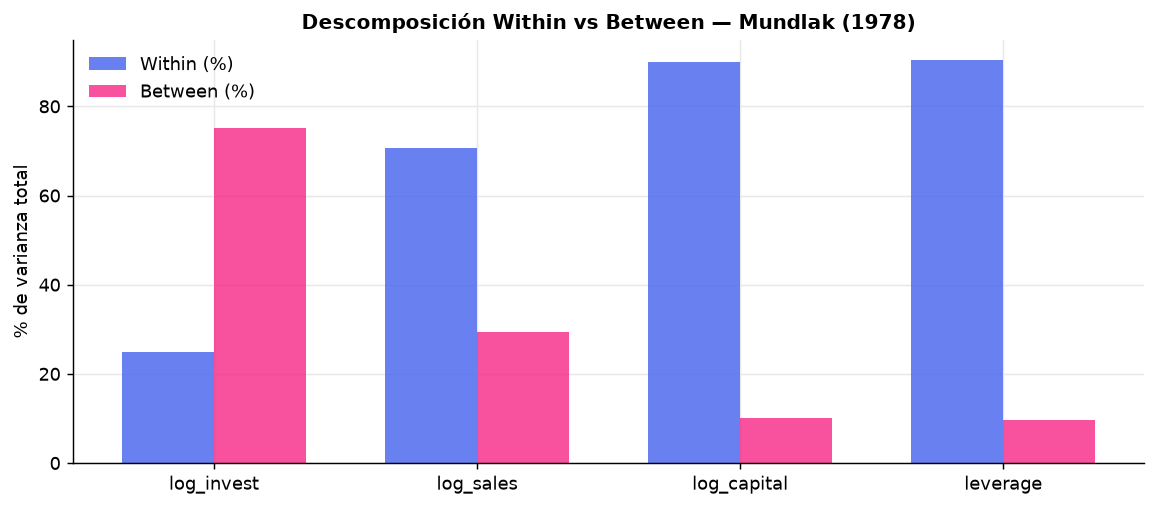

In [2]:
# Balance del panel
obs_per_firm = df.groupby('firm_id').size()
obs_per_year = df.groupby('year').size()

print('─ Balance del panel ─────────────────────────────')
print(f'Obs por firma:  min={obs_per_firm.min()}  max={obs_per_firm.max()}  media={obs_per_firm.mean():.1f}')
print(f'Obs por año:    {obs_per_year.to_dict()}')
print(f'Panel balanceado: {obs_per_firm.nunique() == 1}')

# Descomposición de varianza (Mundlak 1978)
num_vars = ['log_invest', 'log_sales', 'log_capital', 'leverage']

firm_means  = df.groupby('firm_id')[num_vars].transform('mean')
grand_means = df[num_vars].mean()

var_within  = (df[num_vars] - firm_means).var()
var_between = (firm_means - grand_means).var()
var_total   = df[num_vars].var()

var_decomp = pd.DataFrame({
    'Total':   var_total.round(4),
    'Within':  var_within.round(4),
    'Between': var_between.round(4),
    'pct_within':  (var_within / var_total * 100).round(1),
    'pct_between': (var_between / var_total * 100).round(1),
})
print('\nDescomposición de varianza (Within vs Between):')
print(var_decomp.to_string())
print('\nVariables con baja varianza within → FE las identifica con poca precisión.')

# Visualizar varianza within vs between
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(num_vars))
width = 0.35
ax.bar(x - width/2, var_decomp['pct_within'],  width, color='#4361ee', alpha=0.8, label='Within (%)')
ax.bar(x + width/2, var_decomp['pct_between'], width, color='#f72585', alpha=0.8, label='Between (%)')
ax.set_xticks(x)
ax.set_xticklabels(num_vars)
ax.set_ylabel('% de varianza total')
ax.set_title('Descomposición Within vs Between — Mundlak (1978)')
ax.legend()
plt.tight_layout()
plt.show()

## 2 — Visualizar heterogeneidad no observada

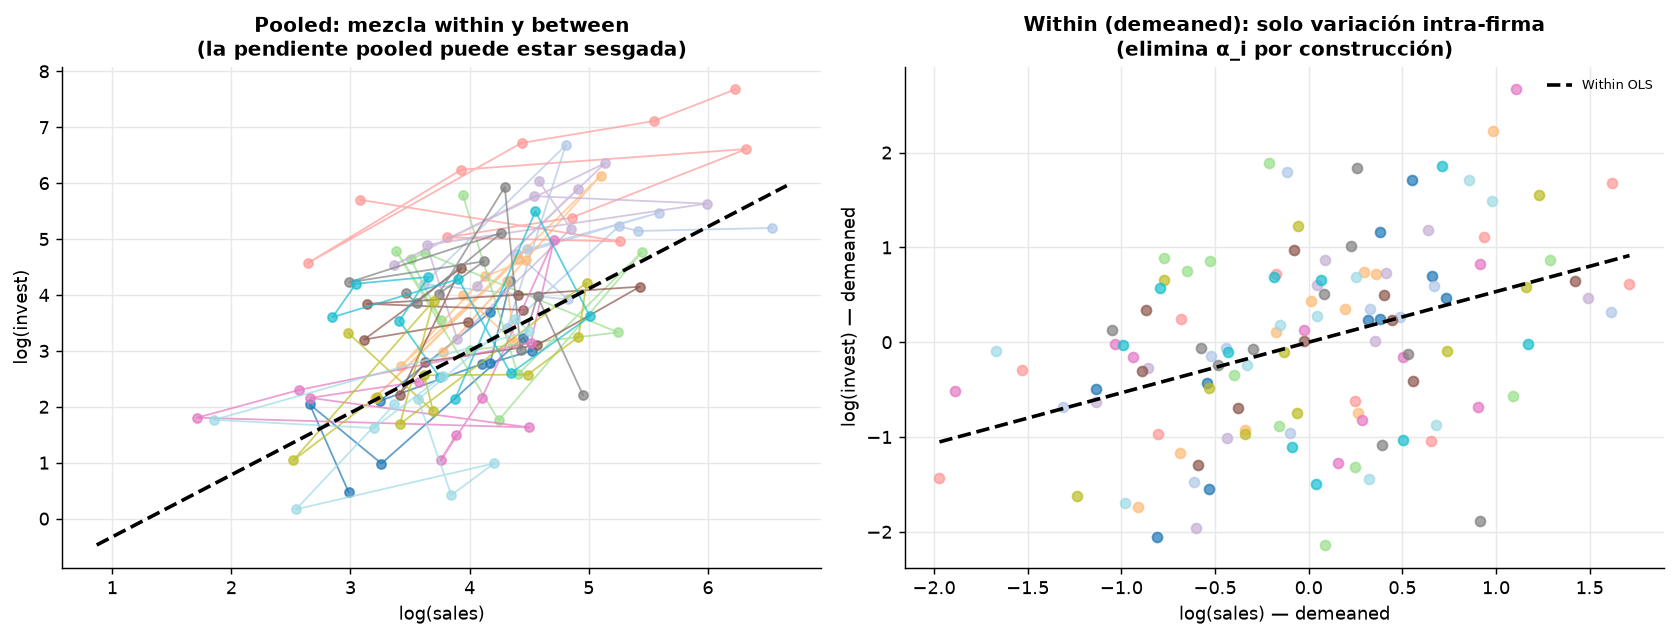

Pendiente Pooled OLS:    1.1094
Pendiente Within (FE):   0.5337
Diferencia = sesgo por variable omitida (α_i correlacionado con log_sales).


In [3]:
# Seleccionar 12 firmas representativas
sample_firms = np.random.choice(df['firm_id'].unique(), 12, replace=False)
df_sample    = df[df['firm_id'].isin(sample_firms)]
colors       = plt.cm.tab20(np.linspace(0, 1, 12))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: log_invest vs log_sales — mezcla efecto within y between
for firm, color in zip(sample_firms, colors):
    d = df_sample[df_sample['firm_id'] == firm]
    axes[0].plot(d['log_sales'], d['log_invest'], 'o-', color=color, markersize=5,
                 alpha=0.7, linewidth=1, label=f'Firma {firm}')
# Regresión pooled OLS (ignora efectos fijos)
slope, intercept, *_ = stats.linregress(df['log_sales'], df['log_invest'])
x_line = np.linspace(df['log_sales'].min(), df['log_sales'].max(), 100)
axes[0].plot(x_line, intercept + slope*x_line, 'k--', linewidth=2, label='Pooled OLS')
axes[0].set_xlabel('log(sales)'); axes[0].set_ylabel('log(invest)')
axes[0].set_title('Pooled: mezcla within y between\n(la pendiente pooled puede estar sesgada)')

# Panel B: demeaned — variación within
df_dm = df_sample.copy()
for col in ['log_sales', 'log_invest']:
    df_dm[col + '_dm'] = df_sample[col] - df_sample.groupby('firm_id')[col].transform('mean')

for firm, color in zip(sample_firms, colors):
    d = df_dm[df_dm['firm_id'] == firm]
    axes[1].scatter(d['log_sales_dm'], d['log_invest_dm'],
                    color=color, s=30, alpha=0.7)
slope_w, intercept_w, *_ = stats.linregress(df_dm['log_sales_dm'], df_dm['log_invest_dm'])
x_line2 = np.linspace(df_dm['log_sales_dm'].min(), df_dm['log_sales_dm'].max(), 100)
axes[1].plot(x_line2, intercept_w + slope_w*x_line2, 'k--', linewidth=2, label='Within OLS')
axes[1].set_xlabel('log(sales) — demeaned'); axes[1].set_ylabel('log(invest) — demeaned')
axes[1].set_title('Within (demeaned): solo variación intra-firma\n(elimina α_i por construcción)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()
print(f'Pendiente Pooled OLS:    {slope:.4f}')
print(f'Pendiente Within (FE):   {slope_w:.4f}')
print('Diferencia = sesgo por variable omitida (α_i correlacionado con log_sales).')

## 3 — Estimadores FE, RE y Pooled OLS

In [4]:
X_vars = ['log_sales', 'log_capital', 'leverage']
y_var  = 'log_invest'

# ── Pooled OLS ──────────────────────────────────────────────────────────
X_pool = sm.add_constant(df[X_vars])
mod_pool = sm.OLS(df[y_var], X_pool).fit(cov_type='cluster',
                                          cov_kwds={'groups': df['firm_id']})

# ── Fixed Effects (Within estimator) ────────────────────────────────────
df_fe = df.copy()
for col in X_vars + [y_var]:
    df_fe[col + '_dm'] = df[col] - df.groupby('firm_id')[col].transform('mean')

X_fe = sm.add_constant(df_fe[[c + '_dm' for c in X_vars]])
mod_fe = sm.OLS(df_fe[y_var + '_dm'], X_fe).fit()
# Corregir grados de libertad: n - N - k (se estiman N efectos fijos)
fe_bse_corrected = mod_fe.bse * np.sqrt(mod_fe.df_resid / (N*T - N - len(X_vars)))

# ── Random Effects (FGLS — Swamy-Arora) ──────────────────────────────────────
# Implementación manual del estimador RE (Baltagi 2008, p. 17)
sigma2_u = mod_fe.mse_resid
firm_means_y = df.groupby('firm_id')[y_var].transform('mean')
firm_means_X = df.groupby('firm_id')[X_vars].transform('mean')
between_resid = (df[y_var] - firm_means_y) - ((df[X_vars] - firm_means_X) @ mod_fe.params[1:]).values
sigma2_alpha  = max(between_resid.var() - sigma2_u / T, 0)
theta         = 1 - np.sqrt(sigma2_u / (T * sigma2_alpha + sigma2_u)) if sigma2_alpha > 0 else 0

df_re = df.copy()
for col in X_vars + [y_var]:
    df_re[col + '_re'] = df[col] - theta * df.groupby('firm_id')[col].transform('mean')

X_re  = sm.add_constant(df_re[[c + '_re' for c in X_vars]])
mod_re = sm.OLS(df_re[y_var + '_re'], X_re).fit()

# Comparar coeficientes
print('COMPARACIÓN DE ESTIMADORES')
print(f'{"Variable":<14} {"Pooled OLS":>12} {"Fixed Effects":>14} {"Random Effects":>15}')
print('─' * 58)
for i, var in enumerate(X_vars):
    b_pool = mod_pool.params.get('const' if var == 'const' else var, np.nan)
    b_fe   = mod_fe.params.iloc[i+1]
    b_re   = mod_re.params.iloc[i+1]
    print(f'{var:<14} {b_pool:>12.4f} {b_fe:>14.4f} {b_re:>15.4f}')

print(f'\nθ (peso FE en RE) = {theta:.4f}  σ²_u={sigma2_u:.4f}  σ²_α={sigma2_alpha:.4f}')
print('θ → 1: RE converge a FE. θ → 0: RE converge a Pooled OLS.')

ValueError: matrices are not aligned

## 4 — Test de Hausman (1978): FE vs RE

$$H = (\hat{\beta}_{FE} - \hat{\beta}_{RE})^\top [Var(\hat{\beta}_{FE}) - Var(\hat{\beta}_{RE})]^{-1} (\hat{\beta}_{FE} - \hat{\beta}_{RE}) \sim \chi^2(k)$$

$H_0$: $E[\alpha_i | X_{it}] = 0$ (efectos no correlacionados → RE es consistente y eficiente)  
$H_1$: $E[\alpha_i | X_{it}] \neq 0$ (efectos correlacionados → solo FE es consistente)

> "The test is based on the idea that under the null hypothesis both estimators are consistent, but under the alternative only FE is." — Hausman (1978, p. 1253)

In [ ]:
b_fe = mod_fe.params.values[1:]      # coeficientes FE (sin constante)
b_re = mod_re.params.values[1:]      # coeficientes RE (sin constante)
diff = b_fe - b_re

var_fe = mod_fe.cov_params().values[1:, 1:]
var_re = mod_re.cov_params().values[1:, 1:]
var_diff = var_fe - var_re

try:
    H_stat = float(diff @ np.linalg.inv(var_diff) @ diff)
    p_val  = 1 - stats.chi2.cdf(H_stat, df=len(X_vars))
except np.linalg.LinAlgError:
    # Si var_diff es singular usar pseudoinversa
    H_stat = float(diff @ np.linalg.pinv(var_diff) @ diff)
    p_val  = 1 - stats.chi2.cdf(H_stat, df=len(X_vars))

print('TEST DE HAUSMAN (1978) — FE vs RE')
print('─' * 55)
print(f'H estadístico: {H_stat:.4f}')
print(f'Grados de libertad: {len(X_vars)}')
print(f'p-value: {p_val:.4f}')
print()
if p_val < 0.05:
    print('→ Rechazar H₀: efectos correlacionados con regresores')
    print('  Usar FIXED EFFECTS — RE es inconsistente')
else:
    print('→ No rechazar H₀: efectos no correlacionados')
    print('  Usar RANDOM EFFECTS — más eficiente que FE')

print('\nDiferencias FE - RE por variable:')
for var, d, fe, re in zip(X_vars, diff, b_fe, b_re):
    print(f'  {var:<15} FE={fe:.4f}  RE={re:.4f}  diff={d:.4f}')

## 5 — Diagnóstico de residuales en panel

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

resid_fe = df_fe[y_var + '_dm'] - mod_fe.fittedvalues
df['resid_fe'] = resid_fe.values

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# 1. Residuales vs Fitted
axes[0,0].scatter(mod_fe.fittedvalues, resid_fe, s=5, alpha=0.3, color='#4361ee')
axes[0,0].axhline(0, color='#f72585', linestyle='--', linewidth=1.5)
axes[0,0].set_xlabel('Fitted'); axes[0,0].set_ylabel('Residuales FE')
axes[0,0].set_title('Residuales vs Fitted')

# 2. Residuales por firma (heterocedasticidad entre firmas)
firm_resid_std = df.groupby('firm_id')['resid_fe'].std().sort_values(ascending=False)
axes[0,1].bar(range(len(firm_resid_std)), firm_resid_std.values, color='#4361ee', alpha=0.7)
axes[0,1].set_xlabel('Firma (ordenada por SD residual)')
axes[0,1].set_ylabel('SD de residuales')
axes[0,1].set_title('Heterocedasticidad entre firmas\n(Baltagi 2008, Cap. 5)')

# 3. Q-Q
(osm, osr), (slope, intercept, r) = stats.probplot(resid_fe, dist='norm')
axes[0,2].scatter(osm, osr, s=5, alpha=0.4, color='#4361ee')
axes[0,2].plot(osm, slope*np.array(osm)+intercept, color='#f72585', linewidth=2)
axes[0,2].set_title(f'Q-Q Residuales FE (r={r:.3f})')

# 4. Autocorrelación serial: ACF de residuales por firma
# Resid en formato panel (firma × tiempo)
resid_panel = df.pivot(index='year', columns='firm_id', values='resid_fe')
mean_acf    = np.array([resid_panel[c].autocorr(lag=1) for c in resid_panel.columns])

axes[1,0].hist(mean_acf, bins=25, color='#f72585', alpha=0.8)
axes[1,0].axvline(0, color='black', linewidth=1.5)
axes[1,0].axvline(mean_acf.mean(), color='#4361ee', linewidth=2, linestyle='--',
                  label=f'Media={mean_acf.mean():.3f}')
axes[1,0].set_xlabel('Autocorrelación lag-1 por firma')
axes[1,0].set_title('Autocorrelación serial intra-firma\n(Wooldridge 2010, Cap. 10)')
axes[1,0].legend(fontsize=8)

# 5. Residuales vs tiempo (efectos temporales no capturados)
year_resid = df.groupby('year')['resid_fe'].mean()
axes[1,1].bar(year_resid.index, year_resid.values, color='#4361ee', alpha=0.8)
axes[1,1].axhline(0, color='#f72585', linestyle='--', linewidth=1.5)
axes[1,1].set_xlabel('Año'); axes[1,1].set_ylabel('Residual medio')
axes[1,1].set_title('Residuales medios por año\n→ Patrón sugiere efectos temporales omitidos')

# 6. Efectos fijos estimados
grand_mean_y   = df.groupby('firm_id')[y_var].mean().mean()
alpha_estimated = (df.groupby('firm_id')[y_var].mean()
                   - df.groupby('firm_id')[X_vars].mean() @ mod_fe.params[1:])
alpha_true_means = pd.Series(
    [alpha_i[ids == i][0] for i in range(N)]
)
axes[1,2].scatter(alpha_true_means, alpha_estimated.values, s=10, alpha=0.6, color='#7209b7')
mn, mx = alpha_true_means.min(), alpha_true_means.max()
axes[1,2].plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='45°')
r_alpha = np.corrcoef(alpha_true_means, alpha_estimated.values)[0,1]
axes[1,2].set_xlabel('α_i verdadero'); axes[1,2].set_ylabel('α_i estimado')
axes[1,2].set_title(f'Efectos fijos: verdadero vs estimado (r={r_alpha:.3f})')
axes[1,2].legend(fontsize=8)

plt.suptitle('Diagnóstico de Residuales — Panel FE', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 — Árbol de decisión: ¿qué estimador usar?

```
¿Los efectos individuales α_i están correlacionados con X_it?
  ¿Hausman p < 0.05?  → Sí → Fixed Effects (FE)
                             → Si T pequeño → considerar también errores robustos
                             → Variables invariantes en t no identificadas

  ¿Hausman p > 0.05?  → No → Random Effects (RE, más eficiente)
                              → Permite identificar variables invariantes

¿Hay shocks temporales comunes (crisis, regulación)?
  → Incluir efectos fijos temporales (Two-Way FE)

¿Autocorrelación serial detectada (ACF lag-1 ≠ 0)?
  → Errores estándar HAC (Driscoll-Kraay) o clustering por firma

¿Heterocedasticidad entre firmas?
  → Clustering por firma (Bertrand, Duflo & Mullainathan 2004)
```

## Resumen

| Diagnóstico | Qué detecta | Solución |
|---|---|---|
| Varianza within/between | Si FE puede identificar el efecto | Si within ≈ 0 → FE poco preciso |
| Hausman test | Si α_i correlaciona con X | p<0.05 → FE; p>0.05 → RE |
| ACF residuales por firma | Autocorrelación serial | SE agrupados (cluster) o HAC |
| SD residuales por firma | Heterocedasticidad entre firmas | Cluster-robust SE |
| Residuales medios por año | Efectos temporales no controlados | Two-way FE (firma + año) |

**Referencias:**
- Hausman, J.A. (1978). Specification tests in econometrics. *Econometrica*, 46(6), 1251–1271.
- Mundlak, Y. (1978). On the pooling of time series and cross section data. *Econometrica*, 46(1).
- Wooldridge, J.M. (2010). *Econometric Analysis of Cross Section and Panel Data* (2nd ed.). MIT Press.
- Baltagi, B.H. (2008). *Econometrics of Panel Data* (4th ed.). Wiley.
- Bertrand, M., Duflo, E. & Mullainathan, S. (2004). How much should we trust differences-in-differences estimates? *QJE*, 119(1).
- Hall, B.H. (1988). The relationship between firm size and firm growth in the US manufacturing sector. *Journal of Industrial Economics*, 35(4).